# Consolidación Poblacional INEI — REUNIS 2015-2026
**Proyecto Final — Diplomado AI UNI**

**Autor:** Alvaro Untiveros

Consolida las proyecciones poblacionales distritales anuales del MINSA/REUNIS
para calcular la tasa de incidencia por 100,000 habitantes (`tasa_x100k`).

**Fuente:** REUNIS MINSA — Población Total Estimada por Distrito 2015-2026  
**Salida:** `poblacion_distrital_2015_2026.parquet`

## 0. Nota metodológica

Los archivos REUNIS tienen **tres estructuras distintas** según el año:

| Grupo | Años | Hoja | Estructura |
|-------|------|------|------------|
| A | 2015-2018 | Única (índice 0) | Headers en fila 5, ubigeo en col 2, total en col 6 |
| B | 2019-2021 | `DISTRITAL` | Headers en fila 5, 6 columnas base |
| C | 2022-2026 | `DISTRITAL` | Headers en fila 5, 7 columnas base (col extra) |

El número de distritos crece de 1,794 (2015) a 1,899 (2026) por creación de
nuevos distritos vía ley. El salto más notable ocurre en 2022 (+distritos nuevos INEI).
Para distritos sin dato en años anteriores a su creación se usará interpolación
hacia atrás (bfill) en el pipeline de fusión.

## 1. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

POB_DIR  = Path('../')
DATA_RAW = Path('../data/raw')

print('Archivos encontrados:')
for f in sorted(POB_DIR.glob('Poblacion Peru *.xlsx')):
    print(f'  {f.name}')

Archivos encontrados:
  Poblacion Peru 2015.xlsx
  Poblacion Peru 2016.xlsx
  Poblacion Peru 2017.xlsx
  Poblacion Peru 2018.xlsx
  Poblacion Peru 2019 Dpto Prov Dist.xlsx
  Poblacion Peru 2020 Dpto Prov Dist Final INEI-actualizado.xlsx
  Poblacion Peru 2021 Dpto Prov Dist sexo.xlsx
  Poblacion Peru 2022 Dpto Prov Dist sexo - Final 14.03.22.xlsx
  Poblacion Peru 2023 Dpto Prov Dist sexo-15.03.23.xlsx
  Poblacion Peru 2024 Dpto Prov Dist sexo-08.01.24.xlsx
  Poblacion Peru 2025 Dpto Prov Dist sexo-20-01-25.xlsx
  Poblacion Peru 2026 Dpto Prov Dist sexo-06-01-26.xlsx


## 2. Lectura por grupo

Cada grupo tiene una función de lectura específica que normaliza
la salida a `[ubigeo, poblacion, ano]`.

In [39]:
def leer_grupo_a(fp, ano):
    """2015-2018: columna 'total poblacion' en posición 59."""
    df = pd.read_excel(fp, sheet_name=0, header=0)
    df['ubigeo']    = df.iloc[:, 2].astype(str).str.zfill(6)
    df['poblacion'] = pd.to_numeric(df.iloc[:, 59], errors='coerce')
    return df[['ubigeo','poblacion']].assign(ano=ano)

def leer_grupo_b(fp, ano):
    """2019-2021: hoja DISTRITAL, headers en fila 6, Total en col 5."""
    df = pd.read_excel(fp, sheet_name='DISTRITAL', header=6)
    df['ubigeo']    = df.iloc[:, 0].astype(str).str.zfill(6)
    df['poblacion'] = pd.to_numeric(df.iloc[:, 4], errors='coerce')
    return df[['ubigeo','poblacion']].assign(ano=ano)


def leer_grupo_c(fp, ano):
    """2022-2026: hoja DISTRITAL, headers en fila 6, Total en col 5."""
    df = pd.read_excel(fp, sheet_name='DISTRITAL', header=6)
    df['ubigeo']    = df.iloc[:, 0].astype(str).str.zfill(6)
    df['poblacion'] = pd.to_numeric(df.iloc[:, 5], errors='coerce')
    return df[['ubigeo','poblacion']].assign(ano=ano)


GRUPOS = {
    **{ano: leer_grupo_a for ano in range(2015, 2019)},
    **{ano: leer_grupo_b for ano in range(2019, 2022)},
    **{ano: leer_grupo_c for ano in range(2022, 2027)},
}
print('Funciones de lectura definidas')

Funciones de lectura definidas


## 3. Consolidación

In [40]:
dfs = []
for ano, leer_fn in GRUPOS.items():
    fps = list(POB_DIR.glob(f'Poblacion Peru {ano}*.xlsx'))
    if not fps:
        print(f'  X No encontrado: {ano}'); continue
    df = leer_fn(fps[0], ano)
    dfs.append(df)
    print(f'  ✓ {ano}: {len(df):,} filas')

df_pob = pd.concat(dfs, ignore_index=True)

# Limpieza
df_pob['ubigeo']    = df_pob['ubigeo'].astype(str).str.strip().str.zfill(6)
df_pob['poblacion'] = pd.to_numeric(df_pob['poblacion'], errors='coerce')
df_pob['ano']       = df_pob['ano'].astype(int)
df_pob = df_pob[
    df_pob['ubigeo'].ne('000000') &   # quitar fila PERÚ total
    df_pob['poblacion'].gt(0) &        # quitar ceros
    df_pob['poblacion'].notna()
]
df_pob['poblacion'] = df_pob['poblacion'].astype(int)
df_pob = df_pob.sort_values(['ubigeo','ano']).reset_index(drop=True)

print(f'\nShape final: {df_pob.shape}')
print(f'Años: {sorted(df_pob.ano.unique())}')

  ✓ 2015: 1,838 filas
  ✓ 2016: 1,854 filas
  ✓ 2017: 1,874 filas
  ✓ 2018: 1,874 filas
  ✓ 2019: 1,879 filas
  ✓ 2020: 1,880 filas
  ✓ 2021: 1,881 filas
  ✓ 2022: 1,896 filas
  ✓ 2023: 1,896 filas
  ✓ 2024: 1,897 filas
  ✓ 2025: 1,897 filas
  ✓ 2026: 1,898 filas

Shape final: (22478, 3)
Años: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 4. Verificación

Distritos únicos por año:
ano
2015    1838
2016    1854
2017    1854
2018    1854
2019    1874
2020    1875
2021    1875
2022    1890
2023    1890
2024    1891
2025    1891
2026    1892


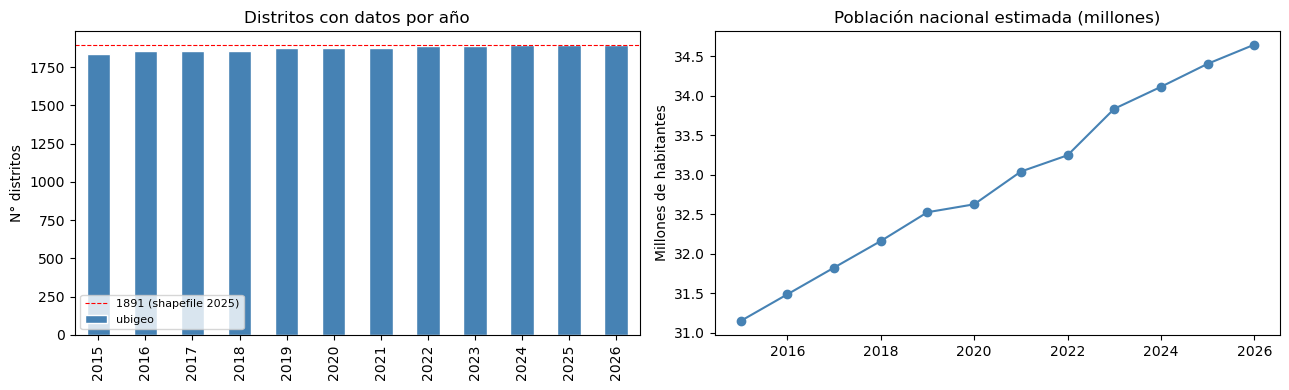

In [41]:
# Distritos por año
dist_x_ano = df_pob.groupby('ano')['ubigeo'].nunique()
print('Distritos únicos por año:')
print(dist_x_ano.to_string())

# Evolución población nacional
pob_nacional = df_pob.groupby('ano')['poblacion'].sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dist_x_ano.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set(title='Distritos con datos por año',
            ylabel='N° distritos', xlabel='')
axes[0].axhline(1891, color='red', linestyle='--', linewidth=0.8,
                label='1891 (shapefile 2025)')
axes[0].legend(fontsize=8)

pob_nacional.plot(ax=axes[1], marker='o', color='steelblue')
axes[1].set(title='Población nacional estimada (millones)',
            ylabel='Millones de habitantes', xlabel='')

plt.tight_layout()

In [43]:
# Verificar ubigeos que no están en el shapefile CDC
cdc_path = DATA_RAW / 'dengue_consolidado_distrital.csv'
if cdc_path.exists():
    ubigeos_cdc = set(
        pd.read_csv(cdc_path, usecols=['ubigeo'])
        ['ubigeo'].astype(str).str.zfill(6)
    )
    ubigeos_pob_2023 = set(df_pob[df_pob.ano==2023]['ubigeo'])

    solo_cdc = ubigeos_cdc - ubigeos_pob_2023
    solo_pob = ubigeos_pob_2023 - ubigeos_cdc

    print(f'Ubigeos en CDC pero no en POB 2023: {len(solo_cdc)}')
    print(f'Ubigeos en POB 2023 pero no en CDC: {len(solo_pob)}')
    print(f'Ubigeos en común: {len(ubigeos_cdc & ubigeos_pob_2023)}')
    if solo_cdc:
        print(f'\nEjemplos solo en CDC: {list(solo_cdc)[:5]}')

Ubigeos en CDC pero no en POB 2023: 1
Ubigeos en POB 2023 pero no en CDC: 0
Ubigeos en común: 1890

Ejemplos solo en CDC: ['130112']


## 5. Guardar parquet

In [47]:
out_path = DATA_RAW / 'poblacion_distrital_2015_2026.parquet'
df_pob.to_parquet(out_path, index=False)
print(f'✓ Guardado: {out_path}')
print(f'  {df_pob.shape[0]:,} filas × {df_pob.shape[1]} columnas')
print(f'  Columnas: {df_pob.columns.tolist()}')
df_pob.head(8)

✓ Guardado: D:\Universidad\Alvaro\Proyecto UNI\UNI\Proyecto\data\raw\poblacion_distrital_2015_2026.parquet
  22,478 filas × 3 columnas
  Columnas: ['ubigeo', 'poblacion', 'ano']


,ubigeo,poblacion,ano
0,010101,28731,2015
1,010101,28814,2016
2,010101,28884,2017
3,010101,28943,2018
4,010101,29041,2019
5,010101,36834,2020
6,010101,39836,2021
7,010101,39041,2022


## 6. Cálculo de `tasa_x100k`

Fusión con el dataset CDC para generar el segundo target del modelo.

$$tasa\_x100k = \\frac{casos}{poblacion} \\times 100{,}000$$

Para semanas epidemiológicas usamos la población del año correspondiente.

In [45]:
if cdc_path.exists():
    df_cdc = pd.read_csv(cdc_path, low_memory=False)
    df_cdc['ubigeo'] = df_cdc['ubigeo'].astype(str).str.zfill(6)
    df_cdc['casos']  = df_cdc['casos'].fillna(0).astype(int)

    # Join por ubigeo + ano
    df_merged = df_cdc.merge(
        df_pob[['ubigeo','ano','poblacion']],
        on=['ubigeo','ano'],
        how='left'
    )

    # Para años sin dato de población (ej. distritos nuevos post-2022)
    # rellenar con el año más cercano disponible
    df_merged['poblacion'] = (
        df_merged.groupby('ubigeo')['poblacion']
        .transform(lambda s: s.ffill().bfill())
    )

    df_merged['tasa_x100k'] = np.where(
        df_merged['poblacion'] > 0,
        df_merged['casos'] / df_merged['poblacion'] * 100_000,
        np.nan
    )

    cobertura = df_merged['tasa_x100k'].notna().mean() * 100
    print(f'Cobertura tasa_x100k: {cobertura:.1f}%')
    print(f'Shape con tasa: {df_merged.shape}')

    # Guardar dataset CDC enriquecido
    out_enriq = DATA_RAW / 'dengue_con_tasa.parquet'
    df_merged.to_parquet(out_enriq, index=False)
    print(f'✓ Guardado: {out_enriq}')

    df_merged[['ubigeo','ano','semana_epi','casos','poblacion','tasa_x100k']].head(8)

Cobertura tasa_x100k: 100.0%
Shape con tasa: (908980, 20)
✓ Guardado: D:\Universidad\Alvaro\Proyecto UNI\UNI\Proyecto\data\raw\dengue_con_tasa.parquet
